# `ZScoreEvaluator`

This notebook provides an empirical demonstration of the expected behavior of a `ZScoreEvaluator`. Its purpose is to make the module's feedback evaluation dynamics observable in a simple setting in which they can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is adaptive normalization of scalar feedback. The `ZScoreEvaluator` maintains running estimates of the feedback mean and variance and uses them to express each new observation relative to its recent feedback history. As those statistics change, the reference against which feedback is evaluated changes with them.

## Conceptual Overview

Within Jacinta, an `Evaluator` is responsible for converting raw feedback into an advantage: a scalar signal that describes how favorable an observation is relative to a reference. A `ZScoreEvaluator` implements this comparison using the z-score of the incoming feedback.

Once its statistics have been initialized, the advantage associated with a feedback value $f$ is

$$
A(f)=\frac{f-\mu}{\sqrt{\sigma^2}+\varepsilon},
$$

where $\mu$ and $\sigma^2$ are the evaluator's current estimates of the feedback mean and variance, and $\varepsilon$ is a small positive constant used for numerical stability. Feedback close to the estimated mean therefore produces an advantage close to zero, while values above or below it produce positive or negative advantages according to their distance from the mean relative to the estimated standard deviation.

The evaluation loop is therefore:

1. The environment produces a scalar feedback value.
2. The `ZScoreEvaluator` compares that value with its current feedback statistics and returns an advantage when those statistics are available.
3. The evaluator incorporates the new feedback into its running estimates so that subsequent observations are evaluated against the updated reference.

The first observations are used to establish that reference. The first feedback initializes the mean, while the second updates the mean and initializes the variance. No advantage is returned during either call. From the third observation onward, the evaluator first calculates the advantage using the statistics accumulated from previous feedback and then updates those statistics with the current value.

### How the feedback statistics are adapted

The reference statistics are not fixed. The `ZScoreEvaluator` maintains its mean and variance through exponential moving updates, allowing both statistics to adapt continuously as new feedback is received.

For the mean, the current deviation

$$
\delta=f-\mu
$$

produces the update

$$
\mu \leftarrow \mu+\alpha_\mu\delta,
$$

where $\alpha_\mu$ is the mean EMA rate. The variance is updated from the same deviation according to

$$
\sigma^2 \leftarrow (1-\alpha_\sigma)\sigma^2+\alpha_\sigma\delta^2,
$$

where $\alpha_\sigma$ is the variance EMA rate.

The EMA rates determine the timescale over which the evaluator adapts. Larger values give recent feedback more influence and allow the estimates to respond more quickly to changes, while smaller values preserve information over a longer history and produce smoother but slower adaptation.

### Scope of the demonstration

The `ZScoreEvaluator` operates on a sequential stream of scalar feedback values. Its behavior therefore depends on how those values evolve over time and on how its internal estimates adapt to that history.

The experiment uses a feedback distribution whose mean and variance change throughout the simulation. This makes it possible to observe both how the evaluator follows changing feedback statistics and how those estimates determine the resulting feedback-advantage mapping.

In [1]:
import math
import random
from collections.abc import Callable

import matplotlib.pyplot as plt

from jacinta.processor.evaluator import ZScoreEvaluator

## Configuration

The parameters below are chosen to make the relevant behavior visible within a short, reproducible run. They provide enough observations for the evaluator statistics to adapt to changes in the feedback distribution, but they should not be interpreted as general-purpose defaults.

### Feedback statistics

Both EMA rates are set to `0.001`, giving recent observations influence over an approximate timescale of one thousand interactions. A higher rate would make the evaluator respond more quickly to changes in the feedback distribution, while a lower rate would produce smoother estimates that adapt more slowly.

### Reproducibility

`SEED = 42` makes the sampled feedback sequence reproducible, `N_STEPS = 10000` supplies enough observations for the evaluator to follow several changes in the feedback distribution, and `N_PLOTS = 5` records approximately evenly spaced snapshots of the feedback-advantage mapping.

In [2]:
# hyperparameters
MEAN_EMA_RATE = 0.001
VAR_EMA_RATE = 0.001

# simulation parameters
N_STEPS = 10000
N_PLOTS = 5
SEED = 42

## Visualization Utilities

The `ZScoreEvaluator` stores the current estimates of the feedback mean and variance, but not the distribution from which the feedback is generated or the history of those estimates. The following helpers expose those statistics and the resulting feedback-advantage mapping solely for inspection; they do not participate in evaluation or adaptation.

`eval_mean_function()` and `eval_var_function()` evaluate the external functions that define the feedback mean and variance at a given simulation step. `plot_feedback_statistics()` uses them to render the resulting Gaussian distribution through its mean and standard deviation over time. This provides the reference against which the evaluator's estimated statistics can later be compared.

`plot_evaluator()` displays the feedback-advantage mapping defined by the evaluator's current state. The estimated mean corresponds to zero advantage, while feedback values above or below it produce positive or negative advantages according to their distance from the mean relative to the estimated standard deviation.

`plot_evaluator_statistics()` renders the evaluator's estimated mean and standard deviation over time. Plotting these statistics beside those of the feedback distribution makes it possible to observe how closely the `ZScoreEvaluator` follows changes in the underlying process.

In [3]:
def eval_mean_function(mean_function: Callable[[int], float], step: int) -> float:
    """
    Safely evaluate a mean function for the given step.

    Args:
        mean_function (Callable[[int], float]): The mean function to evaluate.
        step (int): The simulation step to evaluate the mean function at.

    Returns:
        float: The result of the mean function evaluation.
    """
    try:
        mean = mean_function(step)
        if not math.isfinite(mean):
            mean = math.nan
    except (ArithmeticError, ValueError):
        mean = math.nan
    return mean

In [4]:
def eval_var_function(var_function: Callable[[int], float], step: int) -> float:
    """
    Safely evaluate a variance function for the given step.

    Args:
        var_function (Callable[[int], float]): The variance function to evaluate.
        step (int): The simulation step to evaluate the variance function at.

    Returns:
        float: The result of the variance function evaluation.
    """
    try:
        var = var_function(step)
        if not math.isfinite(var):
            var = math.nan
        var = max(var, 0.0)
    except (ArithmeticError, ValueError):
        var = math.nan
    return var

In [5]:
def plot_feedback_statistics(
    ax: plt.Axes,
    mean_function: Callable[[int], float],
    var_function: Callable[[int], float],
) -> None:
    """
    Plot some feedback statistics.

    Args:
        ax (plt.Axes): The axes to plot on.
        mean_function (Callable[[int], float]): The mean function to plot.
        var_function (Callable[[int], float]): The variance function to plot.
    """
    # get the simulation steps
    steps = list(range(N_STEPS))
    # evaluate the feedback statistics
    means = [eval_mean_function(mean_function, step) for step in steps]
    stds = [math.sqrt(eval_var_function(var_function, step)) for step in steps]
    # plot the feedback statistics
    ax.plot(steps, means, label="Mean")
    for idx, (scale, alpha) in enumerate(
        (
            (1.0, 0.025000),
            (0.8, 0.025641),
            (0.6, 0.052632),
            (0.4, 0.111111),
            (0.2, 0.125000),
        )
    ):
        # get the feedback distribution bounds
        lower_bounds = [
            mean - scale * std for mean, std in zip(means, stds, strict=True)
        ]
        upper_bounds = [
            mean + scale * std for mean, std in zip(means, stds, strict=True)
        ]
        ax.fill_between(
            steps,
            lower_bounds,
            upper_bounds,
            color="C0",
            alpha=alpha,
            label="Mean ± Std" if idx == 4 else None,
        )
    ax.set_xlim(0, N_STEPS)
    ax.set_xlabel("Step")
    ax.set_ylabel("Gaussian Feedback")
    ax.set_title("Gaussian Feedback Statistics")
    ax.grid(visible=True, alpha=0.3)
    ax.legend()
    return

In [6]:
def plot_evaluator(
    ax: plt.Axes,
    evaluator: ZScoreEvaluator,
    n_points: int = 1000,
) -> None:
    """
    Plot the feedback-advantage mapping of an evaluator.

    Args:
        ax (plt.Axes): The axes to plot on.
        evaluator (ZScoreEvaluator): The evaluator to plot.
        n_points (int): The number of points to plot.
            Defaults to 1000.
    """
    # get the evaluator statistics
    mean = evaluator.mean
    std = math.sqrt(evaluator.var)
    # evaluate the feedback-advantage mapping
    min_f = mean - 4.0 * std
    max_f = mean + 4.0 * std
    f_step = (max_f - min_f) / (n_points - 1)
    feedbacks = [min_f + idx * f_step for idx in range(n_points)]
    advantages = [(feedback - mean) / (std + evaluator.eps) for feedback in feedbacks]
    # plot the feedback-advantage mapping
    ax.plot(feedbacks, advantages)
    ax.axvline(mean - std, color="C1", linestyle="--", label="Mean ± Std")
    ax.axvline(mean, color="C0", linestyle="--", label="Mean")
    ax.axvline(mean + std, color="C1", linestyle="--")
    ax.set_xlim(min_f, max_f)
    ax.set_xlabel("Feedback")
    ax.set_ylabel("Advantage")
    ax.set_title("Evaluator Feedback-Advantage Mapping")
    ax.grid(visible=True, alpha=0.3)
    ax.legend()
    return

In [7]:
def plot_evaluator_statistics(
    ax: plt.Axes,
    means: list[float],
    variances: list[float],
) -> None:
    """
    Plot the statistics of an evaluator.

    Args:
        ax (plt.Axes): The axes to plot on.
        means (list[float]): The evaluator means to plot.
        variances (list[float]): The evaluator variances to plot.
    """
    # get the simulation steps
    steps = list(range(len(means)))
    # get the evaluator statistics
    stds = [math.sqrt(var) if math.isfinite(var) else math.nan for var in variances]
    # get the evaluator statistics bounds
    lower_bounds = [mean - std for mean, std in zip(means, stds, strict=True)]
    upper_bounds = [mean + std for mean, std in zip(means, stds, strict=True)]
    # plot the evaluator statistics
    ax.plot(steps, means, label="Mean")
    ax.fill_between(steps, lower_bounds, upper_bounds, alpha=0.125, label="Mean ± Std")
    ax.set_xlim(0, len(means))
    ax.set_xlabel("Step")
    ax.set_ylabel("Evaluator Feedback")
    ax.set_title("Evaluator Feedback Statistics")
    ax.grid(visible=True, alpha=0.3)
    ax.legend()
    return

## Feedback Distribution

The `ZScoreEvaluator` does not determine the feedback it receives, so this playground needs an external process that generates scalar feedback values. In this controlled setting, feedback is sampled from a Gaussian distribution whose mean and variance change over time. This makes the evaluator's adaptation to a non-stationary feedback process directly observable.

The mean moves through several positive and negative regions during the simulation, while the variance changes independently and produces periods with different levels of dispersion. Both statistics are deliberately non-stationary. A fixed Gaussian distribution would show whether the evaluator can estimate a stable reference, whereas the changing distribution also reveals how its running statistics respond when that reference itself moves.

The plotted statistics are shown for explanation, but they are not available to the `ZScoreEvaluator`. The evaluator has no direct knowledge of the underlying distribution or of how its mean and variance evolve over time. At each interaction, it observes only the scalar feedback value that was sampled. Its internal statistics must therefore adapt entirely from the sequence of feedback it receives.

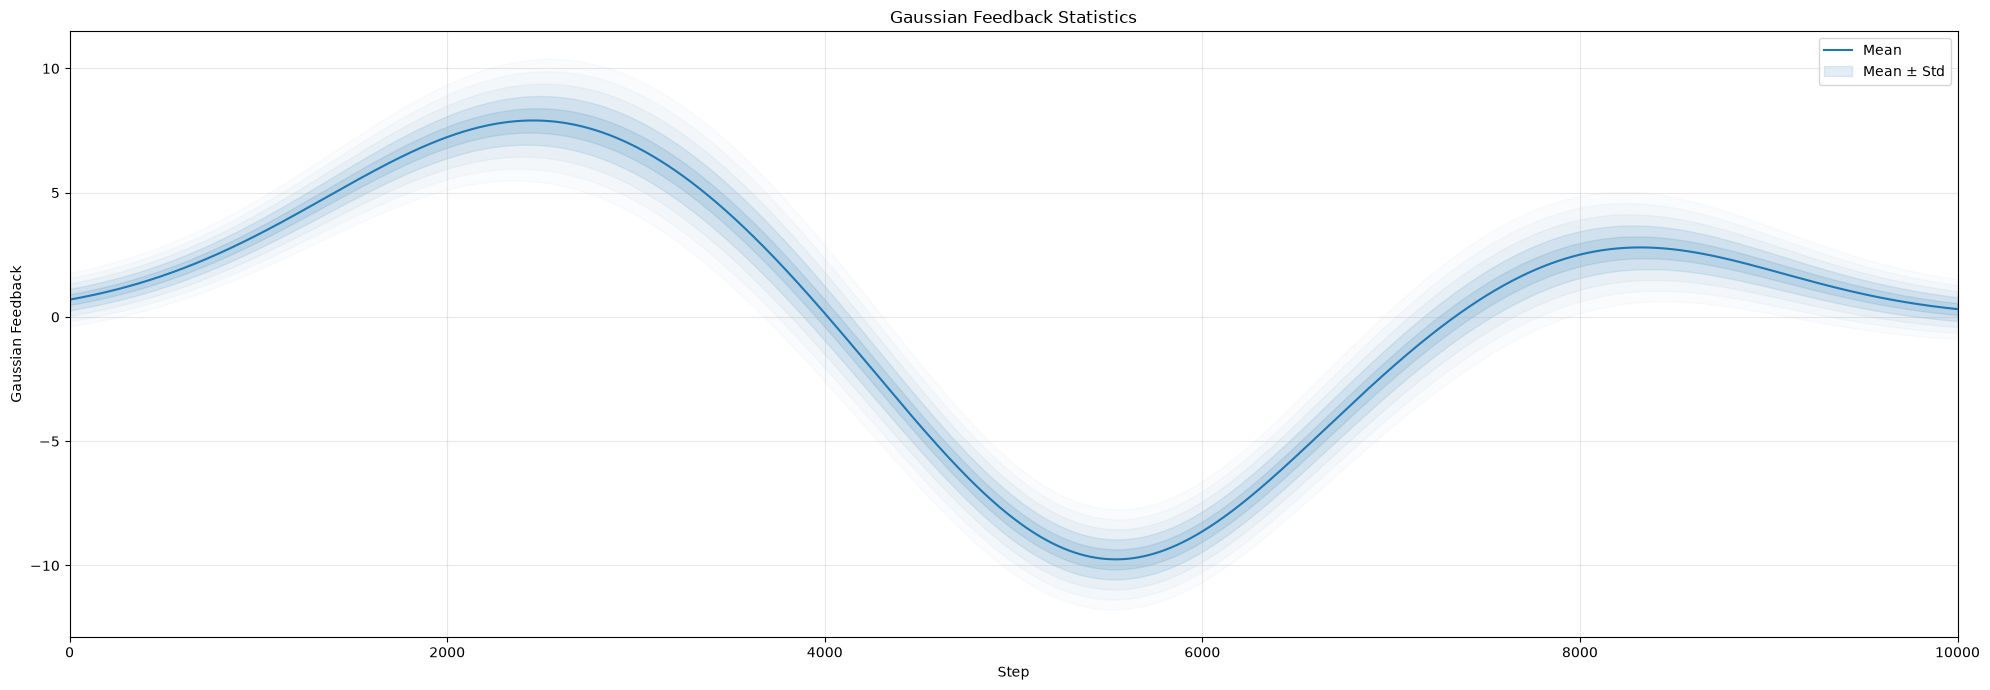

In [8]:
def mean_function(step: int) -> float:
    """
    Mean function.

    Args:
        step (int): The simulation step to evaluate the mean function at.

    Returns:
        float: The mean at the given simulation step.
    """
    mean = (
        8.0 * math.exp(-(((step / (N_STEPS - 1) - 0.25) / 0.16) ** 2))
        - 10.0 * math.exp(-(((step / (N_STEPS - 1) - 0.55) / 0.14) ** 2))
        + 3.0 * math.exp(-(((step / (N_STEPS - 1) - 0.82) / 0.12) ** 2))
    )
    return mean


def var_function(step: int) -> float:
    """
    Variance function.

    Args:
        step (int): The simulation step to evaluate the variance function at.

    Returns:
        float: The variance at the given simulation step.
    """
    var = (
        1.0
        + 7.0 * math.exp(-(((step / (N_STEPS - 1) - 0.35) / 0.18) ** 2))
        + 5.0 * math.exp(-(((step / (N_STEPS - 1) - 0.75) / 0.16) ** 2))
    )
    return var


# plot the feedback statistics
fig, ax = plt.subplots(figsize=(20, 7))
plot_feedback_statistics(ax, mean_function, var_function)
fig.tight_layout()
plt.show()

In [9]:
def sample_feedback(
    step: int,
    mean_function: Callable[[int], float],
    var_function: Callable[[int], float],
    rng: random.Random,
) -> float:
    """
    Sample feedback from the feedback distribution.

    Args:
        step (int): The simulation step at which to sample the feedback.
        mean_function (Callable[[int], float]): The mean function.
        var_function (Callable[[int], float]): The variance function.
        rng (random.Random): The random number generator used for sampling.

    Returns:
        float: The sampled feedback.
    """
    # get the feedback distribution parameters
    mean = eval_mean_function(mean_function, step)
    var = eval_var_function(var_function, step)
    # sample the feedback
    feedback = rng.gauss(mean, math.sqrt(var))
    return feedback

## Simulation

The `ZScoreEvaluator` is exposed to repeated feedback sampled from the changing Gaussian distribution. It begins without an estimated mean or variance and builds both statistics incrementally from the sequence it receives. The random seed makes the sampled sequence reproducible.

Each iteration executes the complete evaluation cycle:

1. `sample_feedback()` draws one scalar feedback value from the Gaussian distribution at the current simulation step.
2. `evaluator()` compares that value with its current mean and variance whenever both statistics have already been initialized.
3. The evaluator updates its running statistics so that subsequent feedback is evaluated against the new reference.

The snapshots display the feedback-advantage mapping implied by the evaluator at different stages of this process. The estimated mean always corresponds to zero advantage, while one estimated standard deviation above or below the mean corresponds approximately to advantages of $1$ and $-1$. Changes in the mean therefore translate the mapping along the feedback axis, whereas changes in the variance alter its slope.

### Reading the snapshots

At step `2`, the evaluator has just received the two observations required to initialize its statistics. Its estimated mean is approximately `0.54` and its estimated standard deviation is approximately `0.03`, so the initial mapping is still determined almost entirely by those first samples.

At step `2501`, the estimated mean has increased to approximately `5.56` and the estimated standard deviation to approximately `3.20`. The zero-advantage point has therefore moved substantially toward the positive feedback region, while the larger estimated variance has reduced the slope of the mapping.

At step `5001`, the estimated mean has fallen to approximately `-1.49` and the estimated standard deviation has increased to approximately `5.70`. The mapping has shifted toward negative feedback values and become considerably flatter as the evaluator adapts to the large change in the feedback process.

At step `7501`, the estimated mean has moved further to approximately `-3.53`, while the estimated standard deviation has decreased to approximately `4.34`. The zero-advantage point therefore remains in the negative region, but the mapping has begun to steepen again as the estimated variance decreases.

By step `10000`, the estimated mean has risen to approximately `0.90` and the estimated standard deviation has fallen to approximately `2.54`. The mapping has consequently moved back toward the final positive region while retaining the smoothing expected from the selected EMA rates.

The important behavior is therefore not convergence to one fixed mapping. Because the feedback process is non-stationary, the mapping itself is expected to evolve: advantage is always defined relative to the feedback statistics represented by the evaluator at that point in the interaction history.

In [10]:
# initialize a ZScoreEvaluator
evaluator = ZScoreEvaluator(
    mean_ema_rate=MEAN_EMA_RATE,
    var_ema_rate=VAR_EMA_RATE,
)

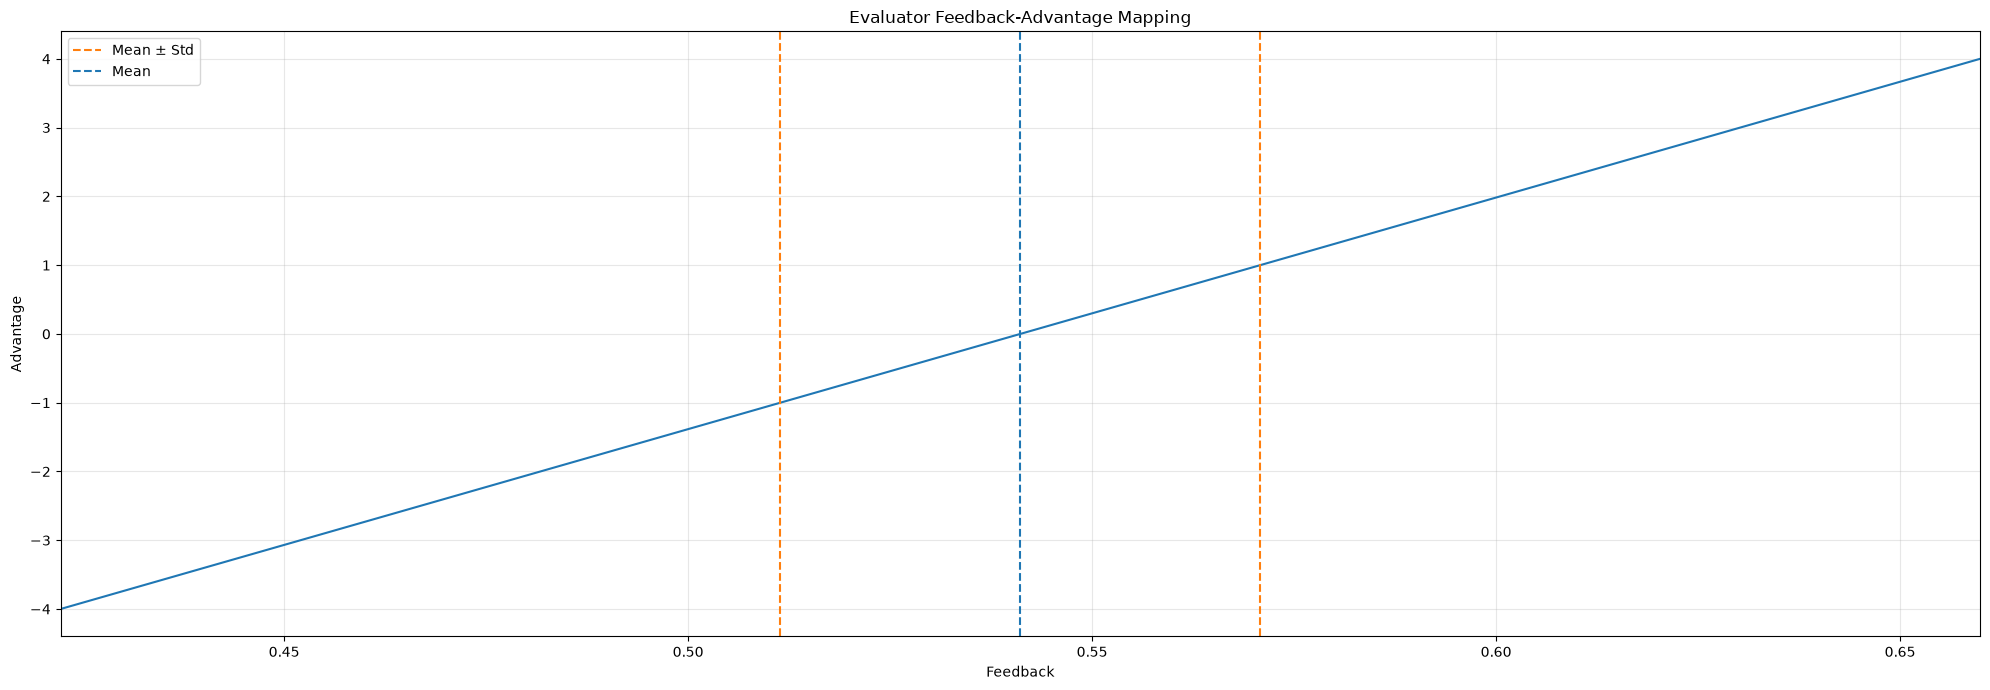

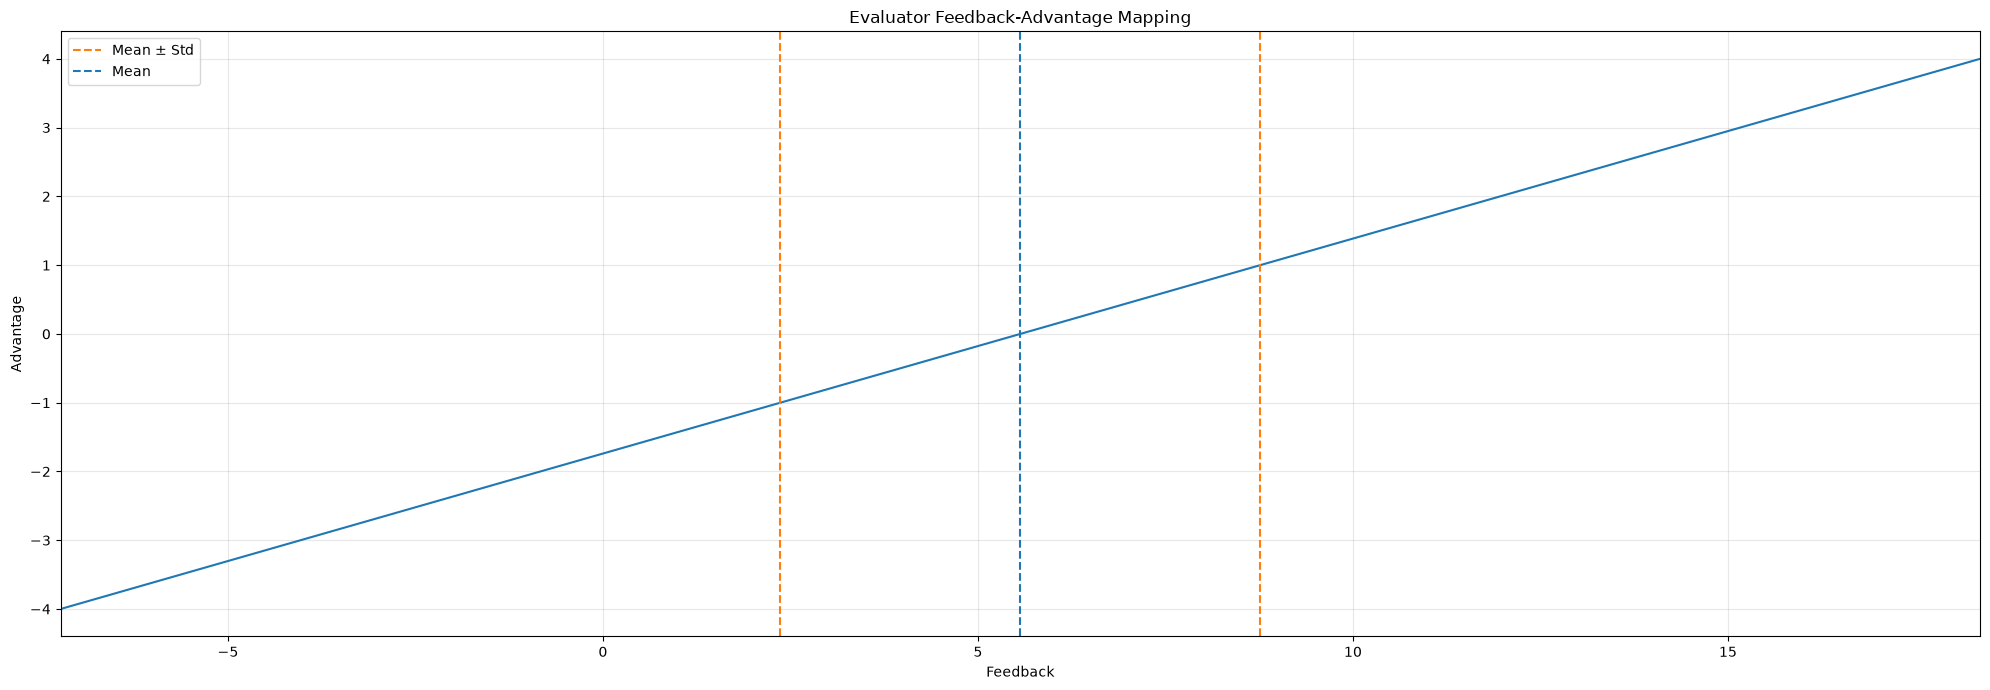

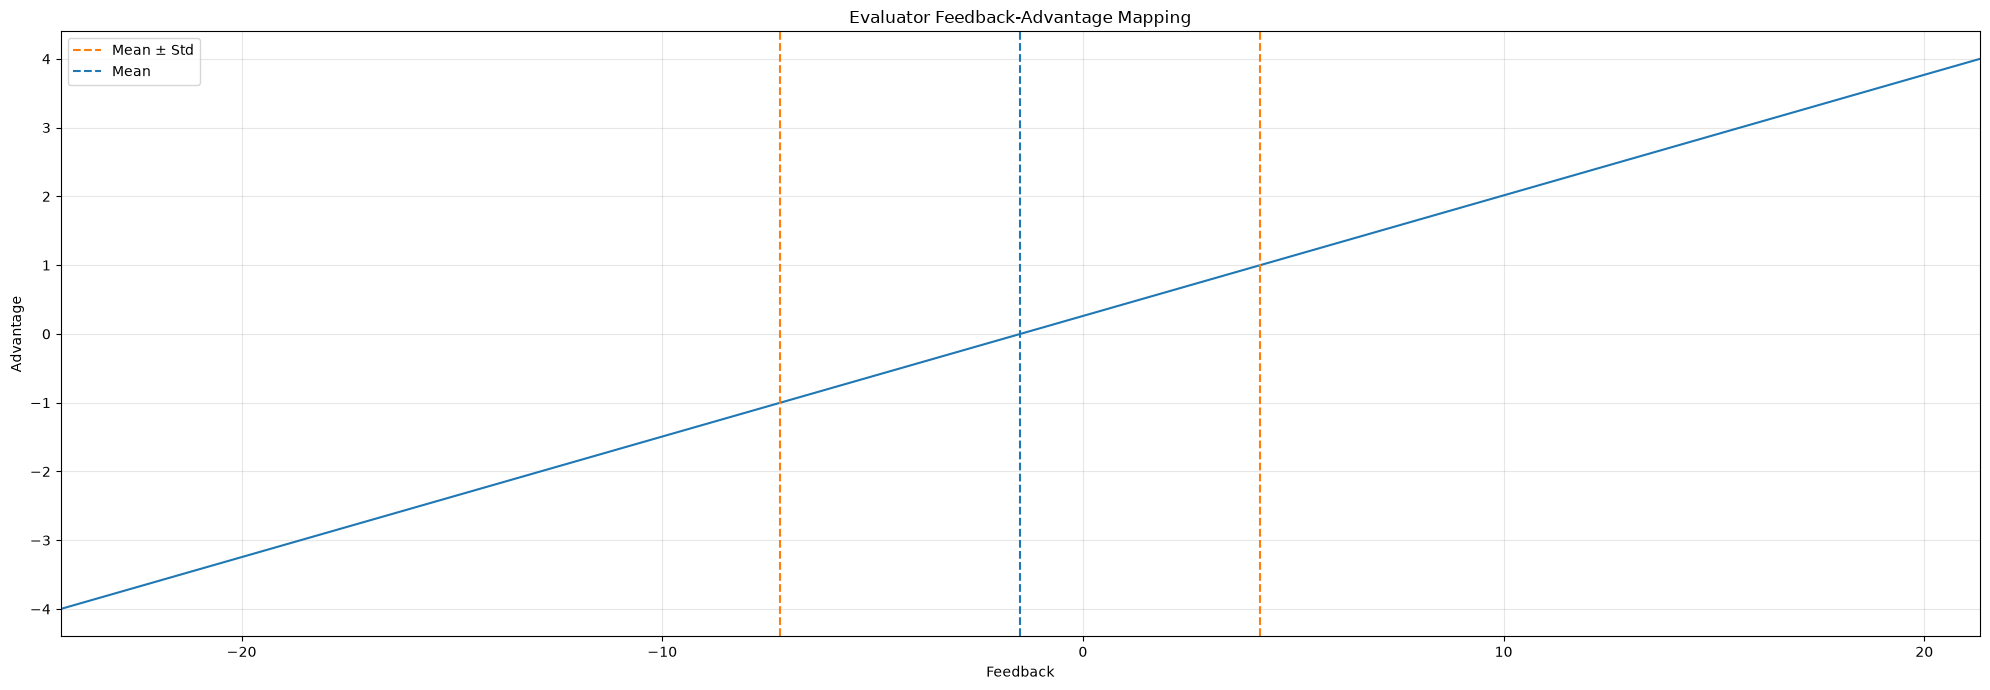

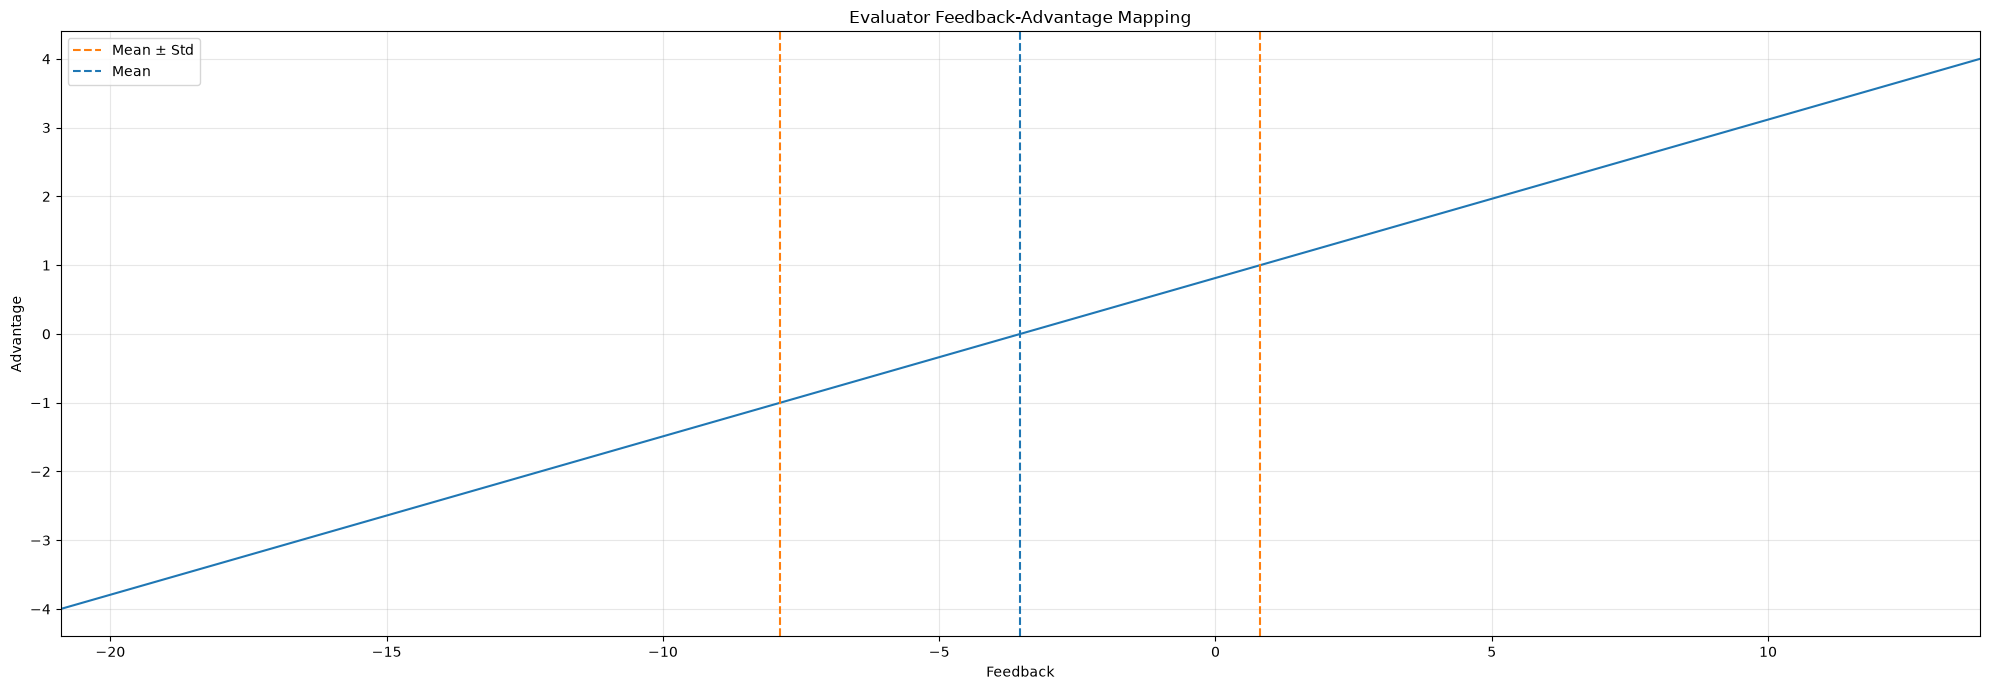

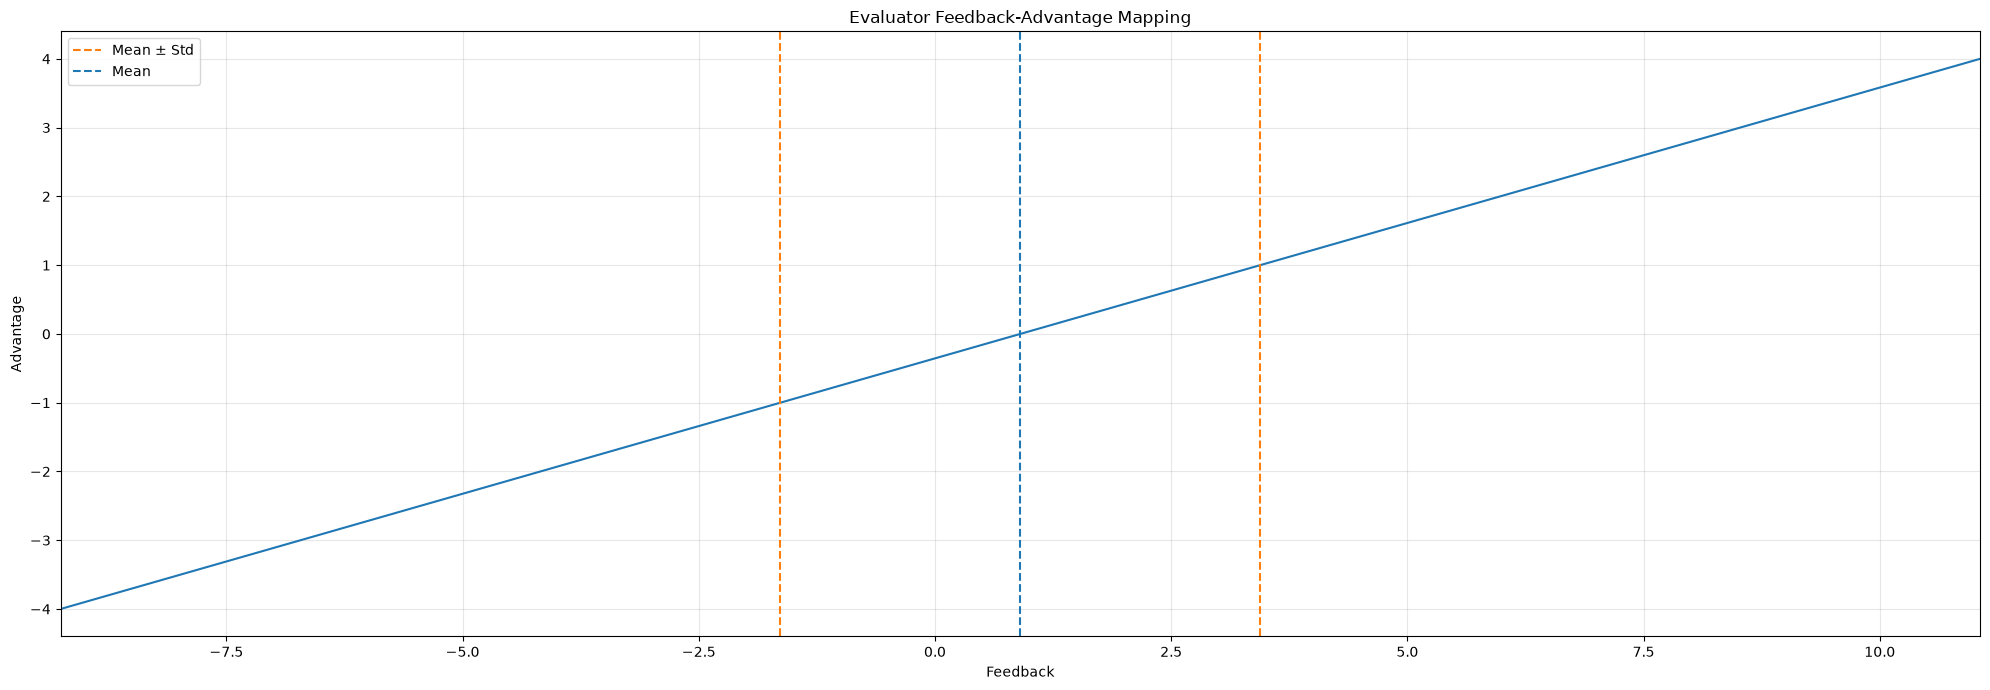

In [11]:
# initialize the random number generator
rng = random.Random(SEED)

# set the evaluator plot steps
plot_steps = (
    {round(1 + idx * (N_STEPS - 2) / (N_PLOTS - 1)) for idx in range(N_PLOTS)}
    if N_PLOTS > 1
    else {N_STEPS - 1}
)

# run simulation
for step in range(N_STEPS):
    print(f"Step {step + 1}/{N_STEPS}", end="\r")
    feedback = sample_feedback(step, mean_function, var_function, rng)
    evaluator(feedback)
    # plot the evaluator
    if step in plot_steps:
        fig, ax = plt.subplots(figsize=(20, 7))
        plot_evaluator(ax, evaluator)
        fig.tight_layout()
        plt.show()

## EMA Rate Comparison

The EMA rates determine how strongly each new feedback value influences the evaluator's running statistics. To make this effect observable, several `ZScoreEvaluator` instances are exposed to the same reproducible feedback sequence while using progressively smaller mean and variance EMA rates.

Each evaluator starts from an empty state and receives exactly the same sampled observations. The underlying feedback statistics are plotted beside the corresponding estimates maintained by the evaluator, so differences between runs are attributable only to the selected EMA rates.

With rates of `0.1`, the estimated mean and standard deviation react rapidly to changes in the feedback process, but both also show substantial short-term fluctuation. Reducing the rates to `0.01` preserves most of that responsiveness while producing noticeably smoother estimates.

At `0.001`, the estimates become substantially smoother but also lag clearly behind the underlying changes. The large positive and negative variations in the feedback mean are still represented, although their peaks are delayed and reduced in magnitude.

With rates of `0.0001`, the evaluator adapts too slowly to follow most of the non-stationary structure within `10000` interactions. At `0.00001`, this effect is even stronger: the statistics change only gradually and behave primarily as a long-term reference over the complete sequence.

The comparison therefore exposes the trade-off controlled by the EMA rates. Larger values favor responsiveness at the cost of greater sensitivity to individual observations, while smaller values favor stability and longer memory at the cost of slower adaptation.

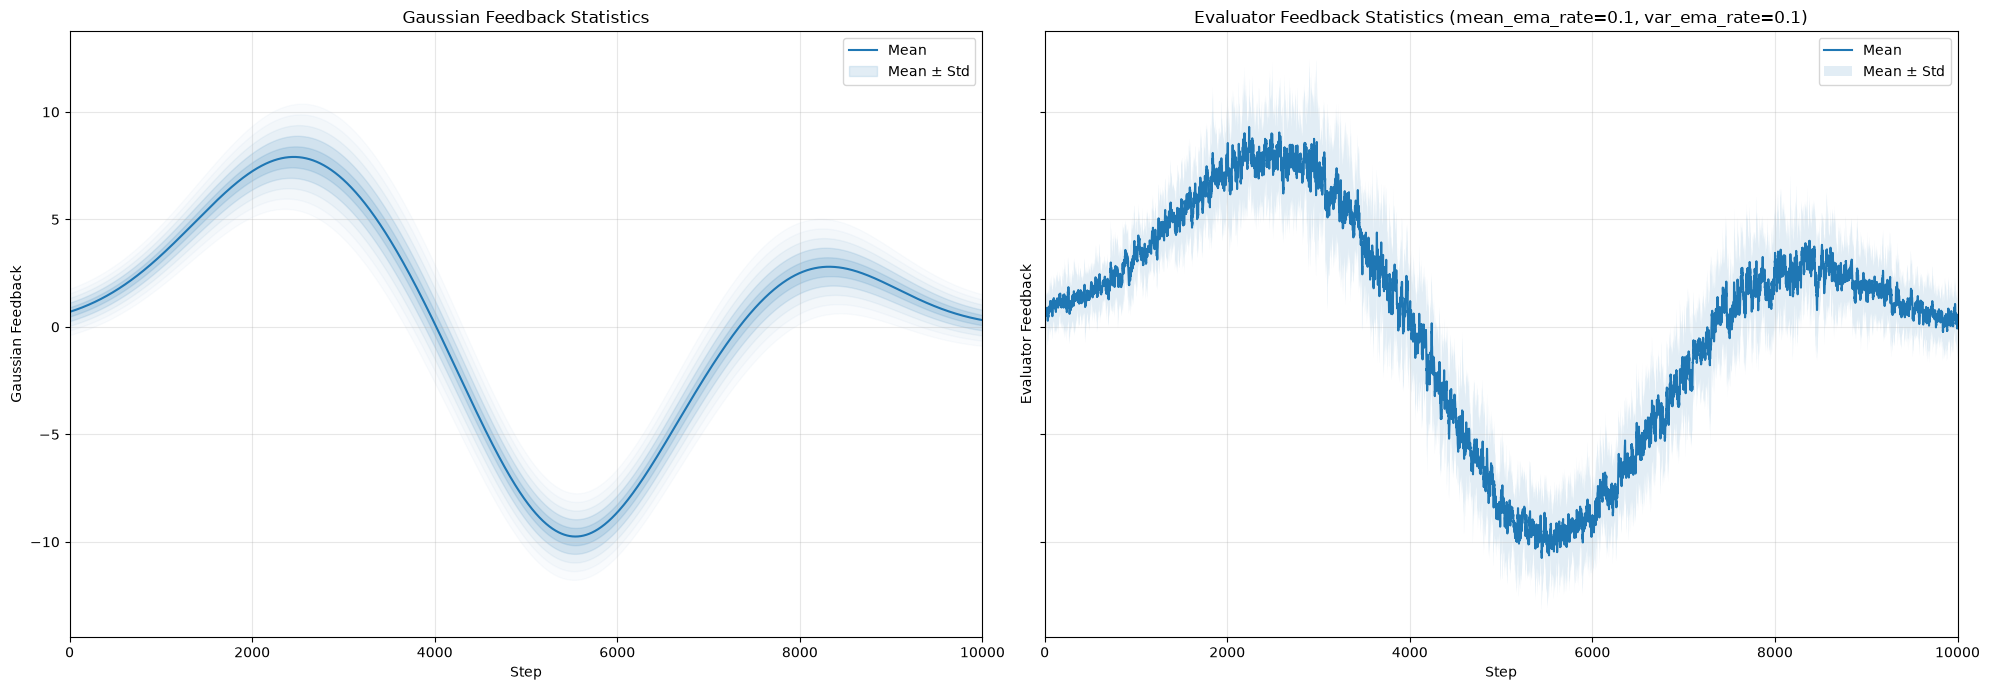

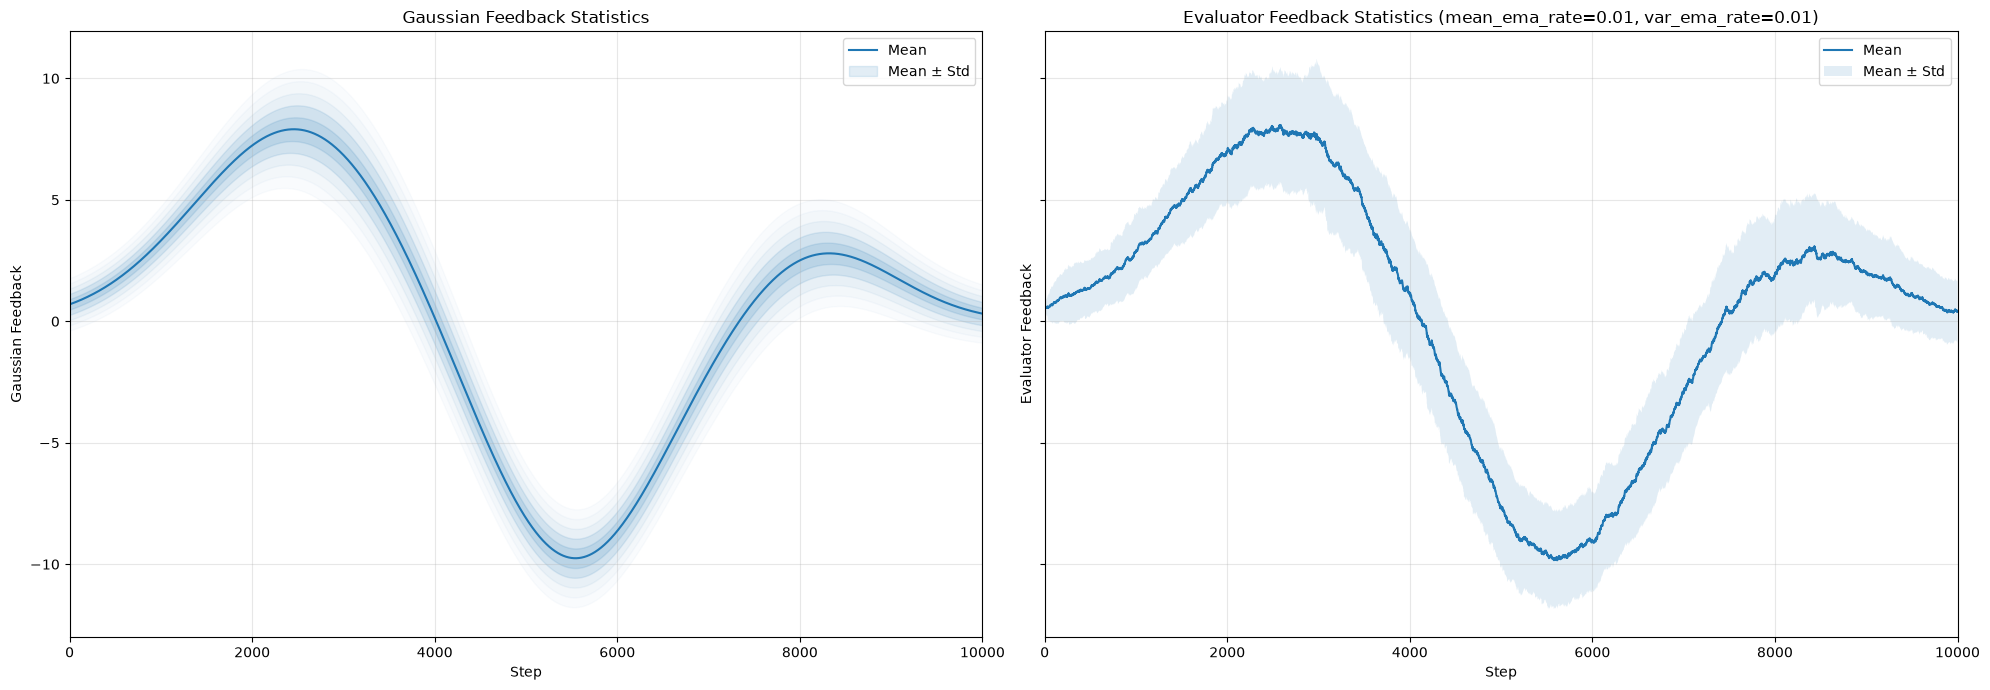

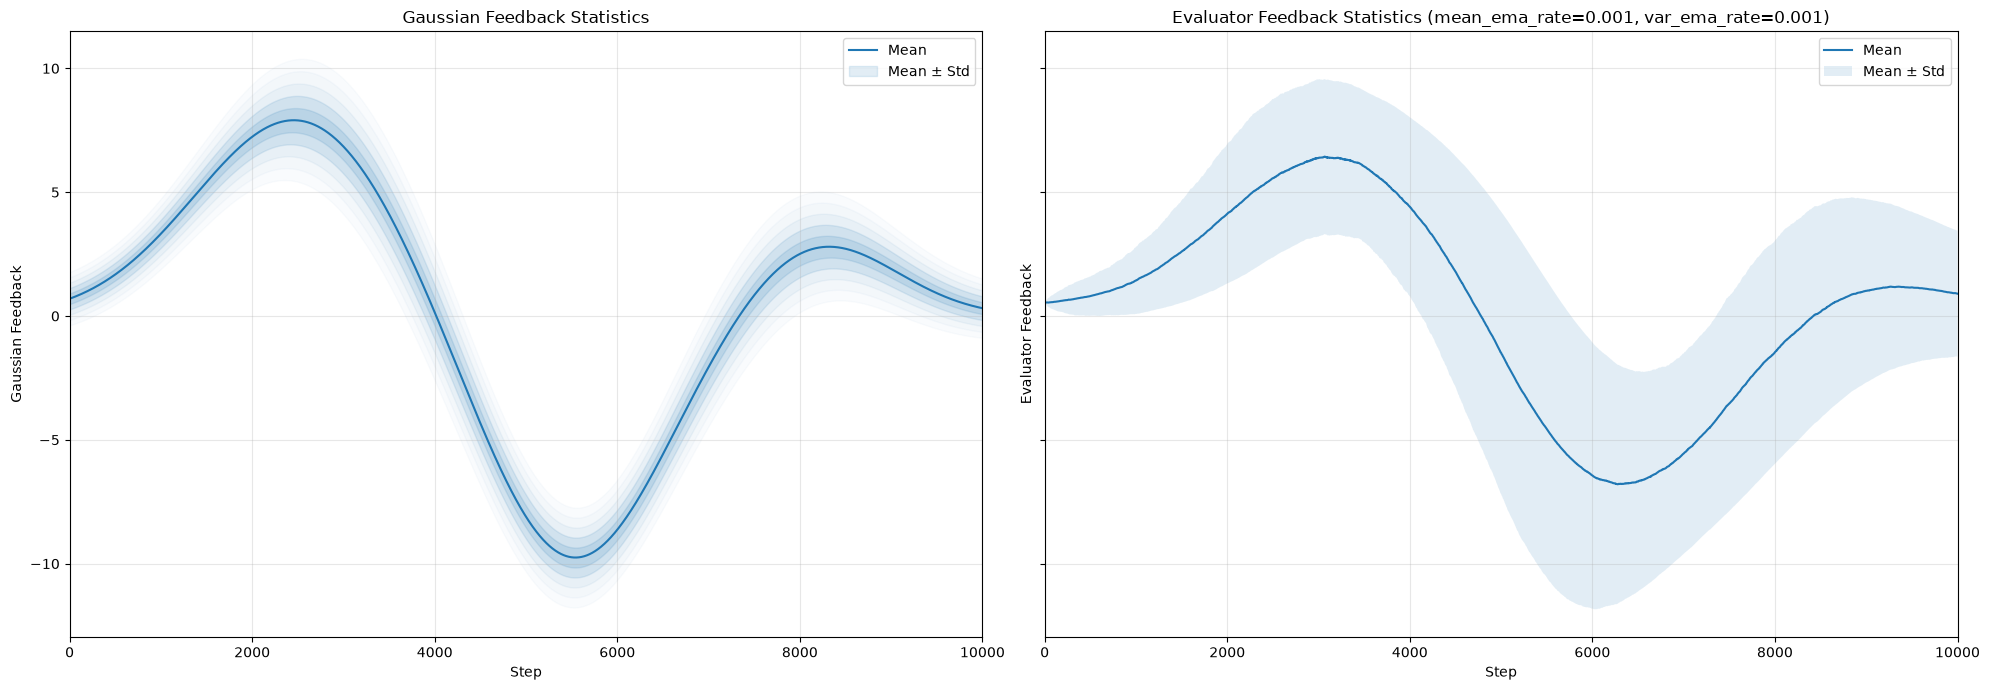

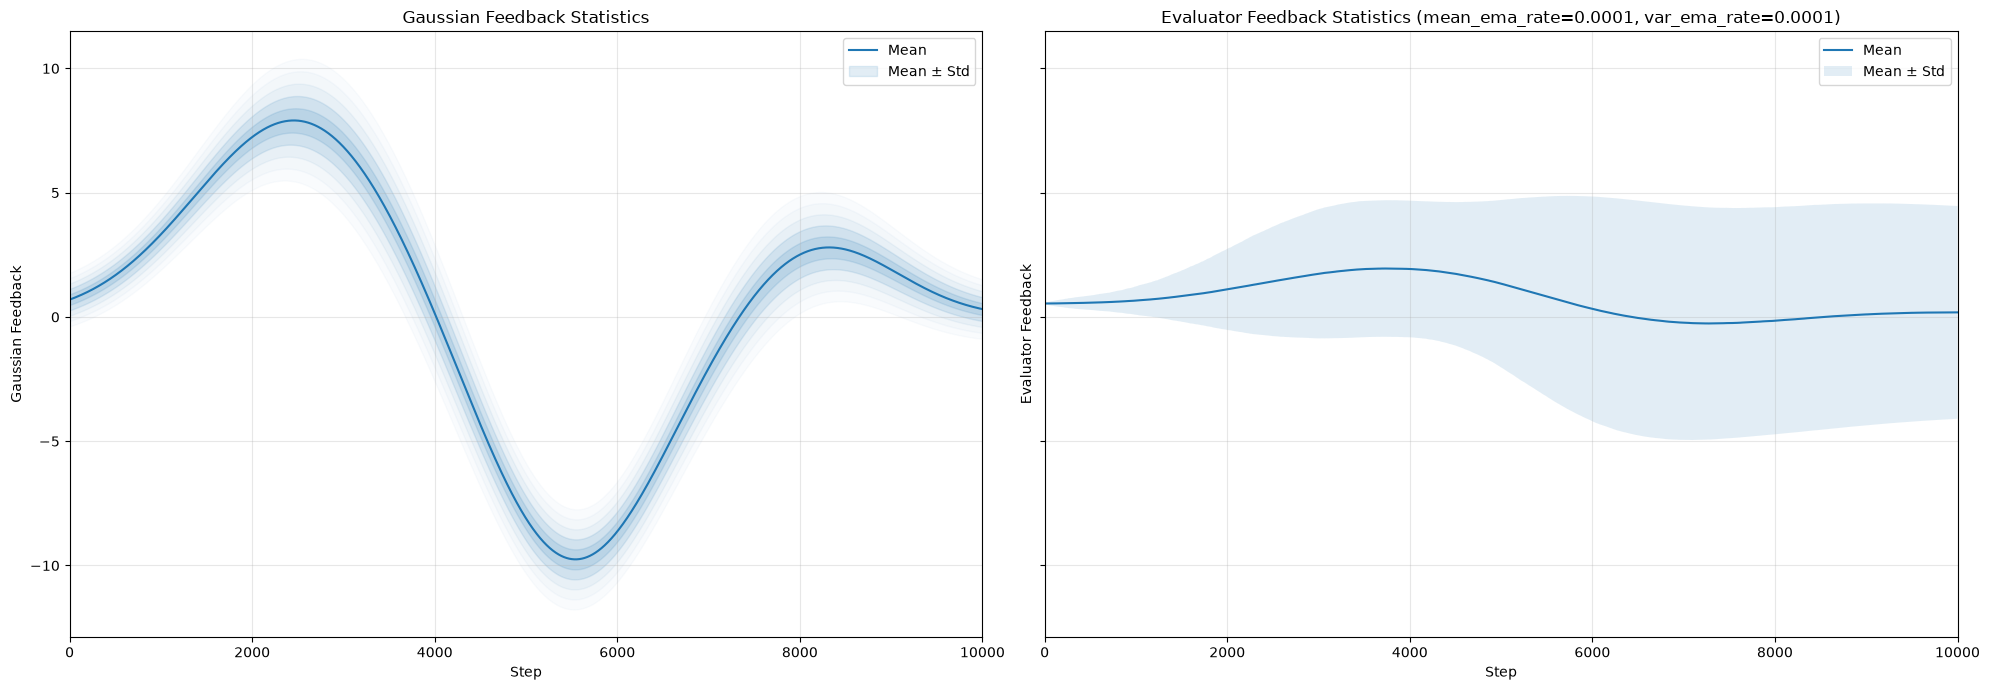

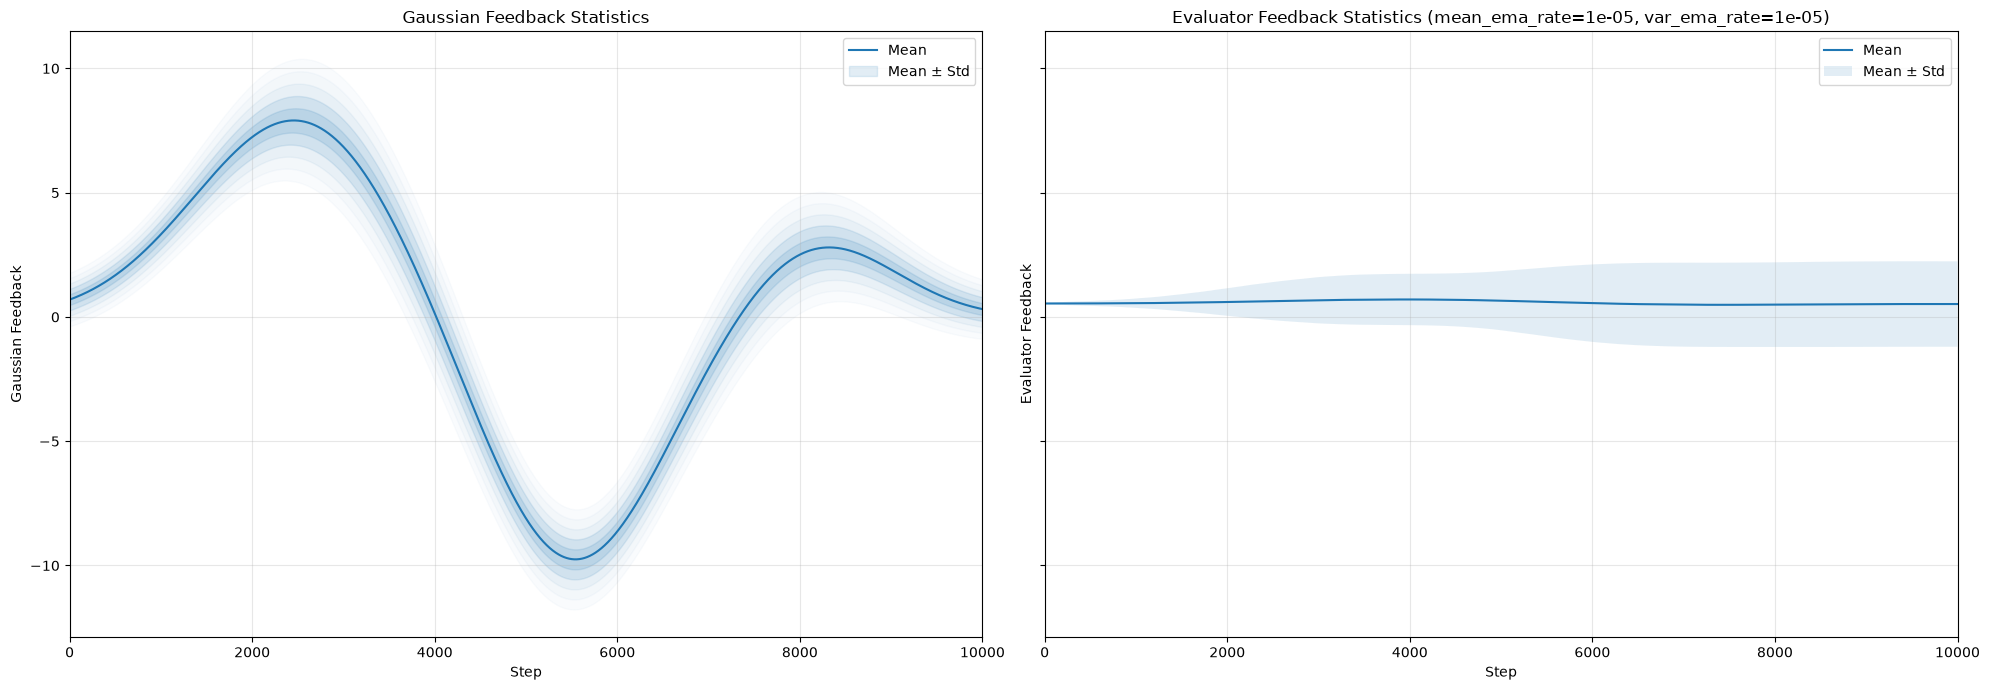

In [12]:
# define the list of EMA rates to evaluate
ema_rates = [
    (0.1, 0.1),
    (0.01, 0.01),
    (0.001, 0.001),
    (0.0001, 0.0001),
    (0.00001, 0.00001),
]

# run simulation for each EMA rate
for mean_ema_rate, var_ema_rate in ema_rates:
    means = []
    variances = []
    # initialize a ZScoreEvaluator
    evaluator = ZScoreEvaluator(
        mean_ema_rate=mean_ema_rate,
        var_ema_rate=var_ema_rate,
    )
    # initialize the random number generator
    rng = random.Random(SEED)
    # run simulation
    for step in range(N_STEPS):
        feedback = sample_feedback(step, mean_function, var_function, rng)
        evaluator(feedback)
        # update the simulation history
        mean = evaluator.mean if evaluator.mean is not None else math.nan
        var = evaluator.var if evaluator.var is not None else math.nan
        means.append(mean)
        variances.append(var)
    # plot the evaluator statistics
    fig, ax = plt.subplots(ncols=2, figsize=(20, 7), sharey=True)
    plot_feedback_statistics(ax[0], mean_function, var_function)
    plot_evaluator_statistics(ax[1], means, variances)
    ax[1].set_title(
        f"Evaluator Feedback Statistics "
        f"(mean_ema_rate={mean_ema_rate}, var_ema_rate={var_ema_rate})"
    )
    fig.tight_layout()
    plt.show()

## Conclusions

This playground provides an empirical view of how a `ZScoreEvaluator` converts scalar feedback into an advantage relative to an adaptive reference. It begins without prior feedback statistics, initializes its mean and variance from the first observations, and then evaluates subsequent feedback according to its distance from the running mean relative to the running standard deviation.

The resulting advantage is therefore contextual rather than absolute. The same feedback value can produce different advantages at different points in the interaction history because both the mean and variance used as its reference evolve as new observations are received.

The experiment also shows that this adaptation is controlled by the EMA rates. Larger rates follow changes in the feedback process more quickly but make the estimated statistics more sensitive to individual samples. Smaller rates produce smoother estimates with longer memory, at the cost of slower adaptation when the underlying distribution changes.

The evaluator requires no direct knowledge of that distribution. It observes only the sequential scalar feedback values presented to it and maintains the statistics needed to interpret future observations relative to that history. Examined in isolation, the module exhibits its intended behavior: it transforms raw feedback into an advantage whose reference adapts continuously to the feedback it receives.